# Análise de Pegada de Carbono Corporativa

## Contexto

---

Você foi contratado como analista de sustentabilidade por uma empresa de tecnologia que está comprometida em reduzir suas emissões de carbono e alcançar a neutralidade climática até 2030. A diretoria precisa entender a distribuição atual das emissões de gases de efeito estufa (GEE) em toda a operação, identificar os principais pontos de emissão, avaliar o progresso em relação às metas estabelecidas e comparar o desempenho entre diferentes departamentos e instalações. Sua missão é utilizar **Pandas** para processar os dados de emissões e criar visualizações com **Matplotlib** e **Seaborn** que ajudem a empresa a tomar decisões estratégicas sobre suas iniciativas de sustentabilidade.

## Objetivos de Aprendizagem

---

Ao final deste exercício, você será capaz de:

- Explorar e validar dados de emissões de carbono corporativas
- Calcular métricas de sustentabilidade (emissões totais, intensidade de carbono, progresso em metas)
- Agrupar emissões por escopo, departamento e tipo de fonte
- Filtrar dados com base em critérios de performance ambiental
- Criar visualizações que comuniquem o impacto climático da organização
- Categorizar fontes de emissão por nível de prioridade de redução

## Competências a Serem Desenvolvidas

---

- Exploração de dados ambientais com estatísticas descritivas
- Criação de colunas derivadas para cálculo de emissões totais e intensidade de carbono
- Agrupamento de dados por escopo GHG Protocol, departamento e categoria
- Aplicação de filtros para identificar maiores emissores e oportunidades de redução
- Categorização de emissões com `pd.cut()` e manipulação de datas com `pd.to_datetime()`
- Construção de gráficos com Matplotlib e Seaborn (barras, linhas, heatmaps e gráficos de área)

## Conjunto de Dados

---

Crie um DataFrame com os seguintes dados:

```python
{
    'Registro_ID': [301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312],
    'Departamento': ['TI', 'Operações', 'TI', 'Facilities', 'Logística', 'TI', 'Operações', 'Facilities', 'Logística', 'Marketing', 'TI', 'Operações'],
    'Fonte_Emissao': ['Data Center', 'Frota Veículos', 'Servidores', 'Eletricidade', 'Transporte Carga', 'Cloud Computing', 'Equipamentos', 'Gás Natural', 'Transporte Aéreo', 'Eventos', 'Equipamentos TI', 'Climatização'],
    'Escopo_GHG': ['Escopo 2', 'Escopo 1', 'Escopo 2', 'Escopo 2', 'Escopo 3', 'Escopo 3', 'Escopo 2', 'Escopo 1', 'Escopo 3', 'Escopo 3', 'Escopo 2', 'Escopo 2'],
    'Emissoes_tCO2e': [45.5, 38.2, 28.3, 52.1, 67.8, 12.4, 31.5, 22.7, 89.3, 15.6, 19.8, 41.2],
    'Meta_Reducao_Percentual': [20, 25, 20, 15, 30, 40, 15, 25, 30, 10, 20, 15],
    'Custo_Compensacao_Reais': [2275.0, 1910.0, 1415.0, 2605.0, 3390.0, 620.0, 1575.0, 1135.0, 4465.0, 780.0, 990.0, 2060.0],
    'Periodo': ['2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q2', '2024-Q2', '2024-Q2', '2024-Q2', '2024-Q3', '2024-Q3'],
    'Instalacao': ['Sede SP', 'Sede SP', 'Filial RJ', 'Sede SP', 'Centro Dist.', 'Cloud', 'Sede SP', 'Filial RJ', 'Centro Dist.', 'Sede SP', 'Filial RJ', 'Sede SP'],
    'Acao_Mitigacao': ['Energia Renovável', 'Eletrificação Frota', 'Virtualização', 'Painéis Solares', 'Otimização Rotas', 'Servidores Eficientes', 'Equipamentos Eficientes', 'Isolamento Térmico', 'Compensação Carbono', 'Eventos Virtuais', 'Reciclagem Equipamentos', 'HVAC Eficiente']
}
```

**Descrição das Colunas:**

- `Registro_ID`: Identificador único do registro de emissão
- `Departamento`: Área responsável pela fonte de emissão
- `Fonte_Emissao`: Descrição específica da fonte emissora
- `Escopo_GHG`: Classificação segundo GHG Protocol (Escopo 1: emissões diretas, Escopo 2: energia comprada, Escopo 3: cadeia de valor)
- `Emissoes_tCO2e`: Emissões em toneladas de CO₂ equivalente
- `Meta_Reducao_Percentual`: Meta de redução estabelecida para a fonte (%)
- `Custo_Compensacao_Reais`: Custo estimado para compensar/neutralizar as emissões
- `Periodo`: Trimestre de medição
- `Instalacao`: Local/instalação da empresa
- `Acao_Mitigacao`: Iniciativa planejada ou implementada para redução

## Dependências e Configurações

---

In [1]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# estilo para visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# visualização pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## Carga de Dados

---

In [2]:
try:
    df = pd.DataFrame(
        {
            'Registro_ID': [301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312],
            'Departamento': ['TI', 'Operações', 'TI', 'Facilities', 'Logística', 'TI', 'Operações', 'Facilities', 'Logística', 'Marketing', 'TI', 'Operações'],
            'Fonte_Emissao': ['Data Center', 'Frota Veículos', 'Servidores', 'Eletricidade', 'Transporte Carga', 'Cloud Computing', 'Equipamentos', 'Gás Natural', 'Transporte Aéreo', 'Eventos', 'Equipamentos TI', 'Climatização'],
            'Escopo_GHG': ['Escopo 2', 'Escopo 1', 'Escopo 2', 'Escopo 2', 'Escopo 3', 'Escopo 3', 'Escopo 2', 'Escopo 1', 'Escopo 3', 'Escopo 3', 'Escopo 2', 'Escopo 2'],
            'Emissoes_tCO2e': [45.5, 38.2, 28.3, 52.1, 67.8, 12.4, 31.5, 22.7, 89.3, 15.6, 19.8, 41.2],
            'Meta_Reducao_Percentual': [20, 25, 20, 15, 30, 40, 15, 25, 30, 10, 20, 15],
            'Custo_Compensacao_Reais': [2275.0, 1910.0, 1415.0, 2605.0, 3390.0, 620.0, 1575.0, 1135.0, 4465.0, 780.0, 990.0, 2060.0],
            'Periodo': ['2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q1', '2024-Q2', '2024-Q2', '2024-Q2', '2024-Q2', '2024-Q3', '2024-Q3'],
            'Instalacao': ['Sede SP', 'Sede SP', 'Filial RJ', 'Sede SP', 'Centro Dist.', 'Cloud', 'Sede SP', 'Filial RJ', 'Centro Dist.', 'Sede SP', 'Filial RJ', 'Sede SP'],
            'Acao_Mitigacao': ['Energia Renovável', 'Eletrificação Frota', 'Virtualização', 'Painéis Solares', 'Otimização Rotas', 'Servidores Eficientes', 'Equipamentos Eficientes', 'Isolamento Térmico', 'Compensação Carbono', 'Eventos Virtuais', 'Reciclagem Equipamentos', 'HVAC Eficiente']
        }
    )
    print('\n=== DADOS CARREGADOS ===')
except Exception as e:
    raise ValueError(f'Erro ao carregar dados: {str(e)}')


=== DADOS CARREGADOS ===


## Tarefas

---

### 1. Exploração Inicial

---

- Exibir as cinco primeiras linhas do DataFrame  
    _Dica: Utilize um método que permite visualizar as primeiras entradas de um DataFrame._
    
- Verificar a existência de valores ausentes  
    _Dica: Explore funções que ajudam a identificar dados nulos em cada coluna._
    
- Apresentar estatísticas descritivas das colunas `Emissoes_tCO2e`, `Meta_Reducao_Percentual` e `Custo_Compensacao_Reais`  
    _Dica: Utilize métodos que geram resumos estatísticos para colunas numéricas._
    
- **Visualização**: Criar um gráfico de dispersão com Matplotlib/Seaborn, relacionando `Emissoes_tCO2e` (eixo x) e `Custo_Compensacao_Reais` (eixo y), com cores diferenciadas por `Escopo_GHG`  
    _Dica: Use plt.scatter() ou sns.scatterplot() para visualizar a relação entre emissões e custos de compensação._
    

In [3]:
# 1.1 head
df.head()

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao
0,301,TI,Data Center,Escopo 2,45.50,20,2275.00,2024-Q1,Sede SP,Energia Renovável
1,302,Operações,Frota Veículos,Escopo 1,38.20,25,1910.00,2024-Q1,Sede SP,Eletrificação Frota
2,303,TI,Servidores,Escopo 2,28.30,20,1415.00,2024-Q1,Filial RJ,Virtualização
3,304,Facilities,Eletricidade,Escopo 2,52.10,15,2605.00,2024-Q1,Sede SP,Painéis Solares
4,305,Logística,Transporte Carga,Escopo 3,67.80,30,3390.00,2024-Q1,Centro Dist.,Otimização Rotas


In [4]:
# 1.2 check ausentes
df.isna().sum()

Registro_ID                0
Departamento               0
Fonte_Emissao              0
Escopo_GHG                 0
Emissoes_tCO2e             0
Meta_Reducao_Percentual    0
Custo_Compensacao_Reais    0
Periodo                    0
Instalacao                 0
Acao_Mitigacao             0
dtype: int64

In [6]:
# 1.3 describe Emissoes_tCO2e, Meta_Reducao_Percentual e Custo_Compensacao_Reais
df['Emissoes_tCO2e Meta_Reducao_Percentual Custo_Compensacao_Reais'.split()].describe()

,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais
count,12.00,12.00,12.00
mean,38.70,22.08,1935.00
std,22.64,8.38,1131.97
min,12.40,10.00,620.00
25%,21.98,15.00,1098.75
50%,34.85,20.00,1742.50
75%,47.15,26.25,2357.50
max,89.30,40.00,4465.00


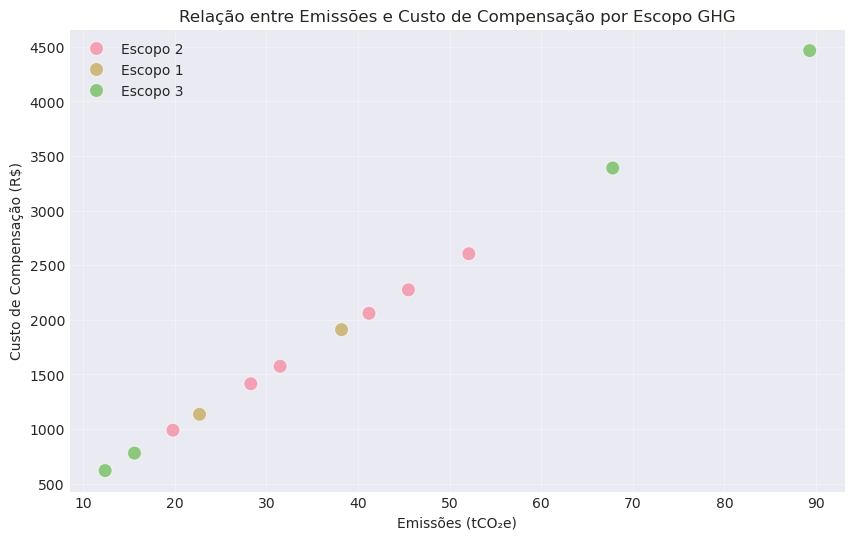

In [20]:
# 1.4 scatter emissoes tco2 vs custo reais com hue em escopo
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Emissoes_tCO2e',
    y='Custo_Compensacao_Reais',
    data=df,
    hue='Escopo_GHG',
    alpha=.6,
    s=100,
)
plt.xlabel('Emissões (tCO₂e)')
plt.ylabel('Custo de Compensação (R$)')
plt.title('Relação entre Emissões e Custo de Compensação por Escopo GHG')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Cálculos Básicos

---

- Criar a coluna `Emissoes_Reduzidas_Meta`, calculando as emissões que seriam reduzidas se a meta fosse atingida (`Emissoes_tCO2e` × `Meta_Reducao_Percentual` / 100)  
    _Dica: Use operações vetoriais para criar colunas derivadas com base em cálculos entre colunas existentes._
    
- Criar a coluna `Emissoes_Apos_Meta`, calculando as emissões residuais após atingir a meta (`Emissoes_tCO2e` - `Emissoes_Reduzidas_Meta`)  
    _Dica: Subtraia as emissões reduzidas do total original._
    
- Criar a coluna `Intensidade_Custo`, calculando o custo de compensação por tonelada de CO₂e (`Custo_Compensacao_Reais` / `Emissoes_tCO2e`)  
    _Dica: Esta métrica mostra a eficiência econômica da compensação._
    
- Calcular o total de emissões atual e o total de emissões projetado após atingir todas as metas  
    _Dica: Utilize funções de agregação como sum() nas colunas apropriadas._
    
- **Visualização**: Construir um gráfico de barras horizontais com Matplotlib mostrando as `Emissoes_tCO2e` por `Fonte_Emissao`, ordenado do maior para o menor  
    _Dica: Use plt.barh() e o método sort_values() para ordenar os dados antes de plotar._
    

In [3]:
# 2.1 criar Emissoes_Reduzidas_Meta = Emissoes_tCO2e` × `Meta_Reducao_Percentual` / 100
df['Emissoes_Reduzidas_Meta'] = df['Emissoes_tCO2e'] * df['Meta_Reducao_Percentual'] / 100
df.sample(3)

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao,Emissoes_Reduzidas_Meta
0,301,TI,Data Center,Escopo 2,45.50,20,2275.00,2024-Q1,Sede SP,Energia Renovável,9.10
10,311,TI,Equipamentos TI,Escopo 2,19.80,20,990.00,2024-Q3,Filial RJ,Reciclagem Equipamentos,3.96
7,308,Facilities,Gás Natural,Escopo 1,22.70,25,1135.00,2024-Q2,Filial RJ,Isolamento Térmico,5.67


In [4]:
# 2.2 criar Emissoes_Apos_Meta = Emissoes_tCO2e` - `Emissoes_Reduzidas_Meta
df['Emissoes_Apos_Meta'] = df['Emissoes_tCO2e'] - df['Emissoes_Reduzidas_Meta']
df.sample(3)

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao,Emissoes_Reduzidas_Meta,Emissoes_Apos_Meta
2,303,TI,Servidores,Escopo 2,28.30,20,1415.00,2024-Q1,Filial RJ,Virtualização,5.66,22.64
1,302,Operações,Frota Veículos,Escopo 1,38.20,25,1910.00,2024-Q1,Sede SP,Eletrificação Frota,9.55,28.65
7,308,Facilities,Gás Natural,Escopo 1,22.70,25,1135.00,2024-Q2,Filial RJ,Isolamento Térmico,5.67,17.02


In [5]:
# 2.3 criar Intensidade_Custo = Custo_Compensacao_Reais / Emissoes_tCO2e
df['Intensidade_Custo'] = df['Custo_Compensacao_Reais']/df['Emissoes_tCO2e']
df.sample(3)

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao,Emissoes_Reduzidas_Meta,Emissoes_Apos_Meta,Intensidade_Custo
3,304,Facilities,Eletricidade,Escopo 2,52.10,15,2605.00,2024-Q1,Sede SP,Painéis Solares,7.82,44.29,50.00
11,312,Operações,Climatização,Escopo 2,41.20,15,2060.00,2024-Q3,Sede SP,HVAC Eficiente,6.18,35.02,50.00
10,311,TI,Equipamentos TI,Escopo 2,19.80,20,990.00,2024-Q3,Filial RJ,Reciclagem Equipamentos,3.96,15.84,50.00


In [6]:
# 2.4 total de emissões atual e o total de emissões projetado após atingir todas as metas  
print(f'Total atual:      {df['Emissoes_tCO2e'].sum():.2f} tCO2')
print(f'Total após metas: {df['Emissoes_Apos_Meta'].sum():.2f} tCO2')
print(f"Redução total:    {df['Emissoes_tCO2e'].sum() - df['Emissoes_Apos_Meta'].sum():.2f} tCO2")

Total atual:      464.40 tCO2
Total após metas: 358.08 tCO2
Redução total:    106.32 tCO2


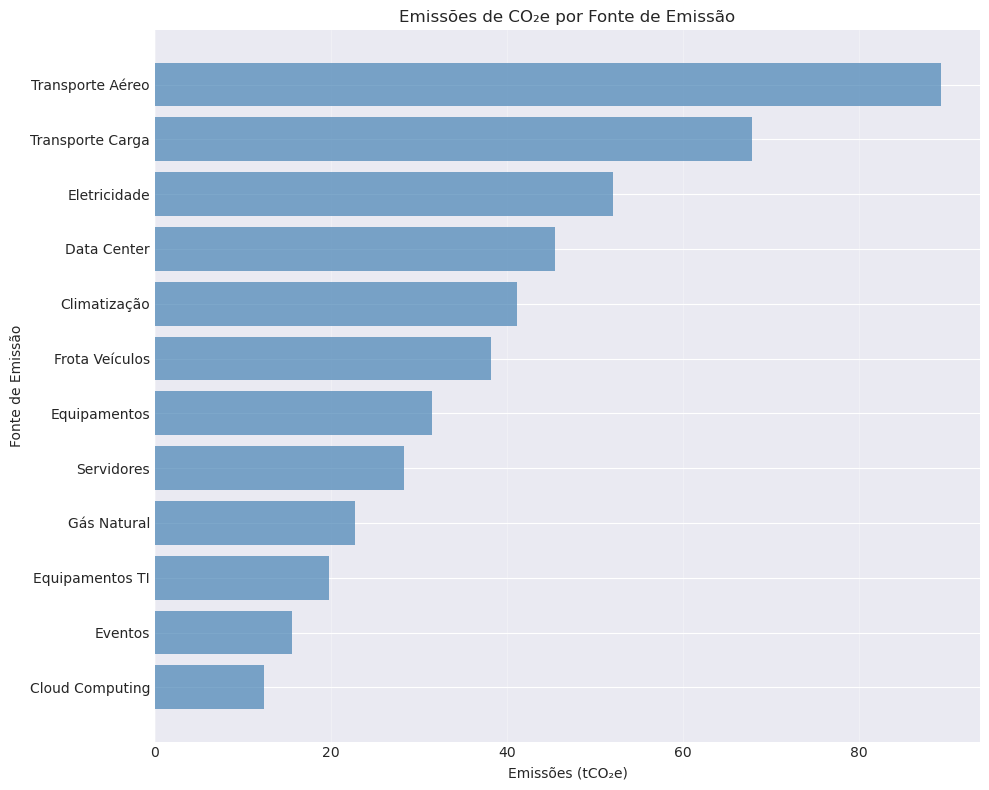

In [7]:
# 2.5 gráfico de barras horizontais com Matplotlib mostrando as `Emissoes_tCO2e` por `Fonte_Emissao`, ordenado do maior para o menor
dados_ordenados = df.sort_values('Emissoes_tCO2e', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(dados_ordenados['Fonte_Emissao'], dados_ordenados['Emissoes_tCO2e'], 
         color='steelblue', alpha=0.7)
plt.xlabel('Emissões (tCO₂e)')
plt.ylabel('Fonte de Emissão')
plt.title('Emissões de CO₂e por Fonte de Emissão')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Análise por Agrupamento

---

- Agrupar os dados por `Escopo_GHG` e calcular a soma das `Emissoes_tCO2e` e a média da `Meta_Reducao_Percentual`  
    _Dica: Utilize o método groupby() e aplique funções de agregação múltiplas._
    
- Agrupar os dados por `Departamento` e calcular o total de emissões e o custo total de compensação  
    _Dica: Após agrupar, use agg() com um dicionário especificando diferentes funções para diferentes colunas._
    
- Agrupar os dados por `Instalacao` e calcular as emissões médias e identificar qual instalação tem maior pegada de carbono  
    _Dica: Use groupby() seguido de mean() ou sum() e depois identifique o máximo._
    
- **Visualização**: Criar um gráfico de barras empilhadas com Matplotlib mostrando a distribuição de emissões por `Escopo_GHG` em cada `Departamento`  
    _Dica: Use pivot_table() para reorganizar os dados e então plot(kind='bar', stacked=True) para criar o gráfico empilhado._
 

In [11]:
# 3.1 agrupar por escopo e somar emissoes e media meta reducao percentual
df.groupby('Escopo_GHG').agg({'Emissoes_tCO2e':'sum', 'Meta_Reducao_Percentual':'mean'})

,Emissoes_tCO2e,Meta_Reducao_Percentual
Escopo_GHG,,
Escopo 1,60.90,25.00
Escopo 2,218.40,17.50
Escopo 3,185.10,27.50


In [13]:
# 3.2 total de emissoes e custo total de compensação por departamento
df.groupby('Departamento')[['Emissoes_tCO2e', 'Custo_Compensacao_Reais']].sum()

,Emissoes_tCO2e,Custo_Compensacao_Reais
Departamento,,
Facilities,74.80,3740.00
Logística,157.10,7855.00
Marketing,15.60,780.00
Operações,110.90,5545.00
TI,106.00,5300.00


In [16]:
# 3.3 emissoes medias por instalação
df.groupby('Instalacao')['Emissoes_tCO2e'].mean().sort_values(ascending=False)

Instalacao
Centro Dist.   78.55
Sede SP        37.35
Filial RJ      23.60
Cloud          12.40
Name: Emissoes_tCO2e, dtype: float64

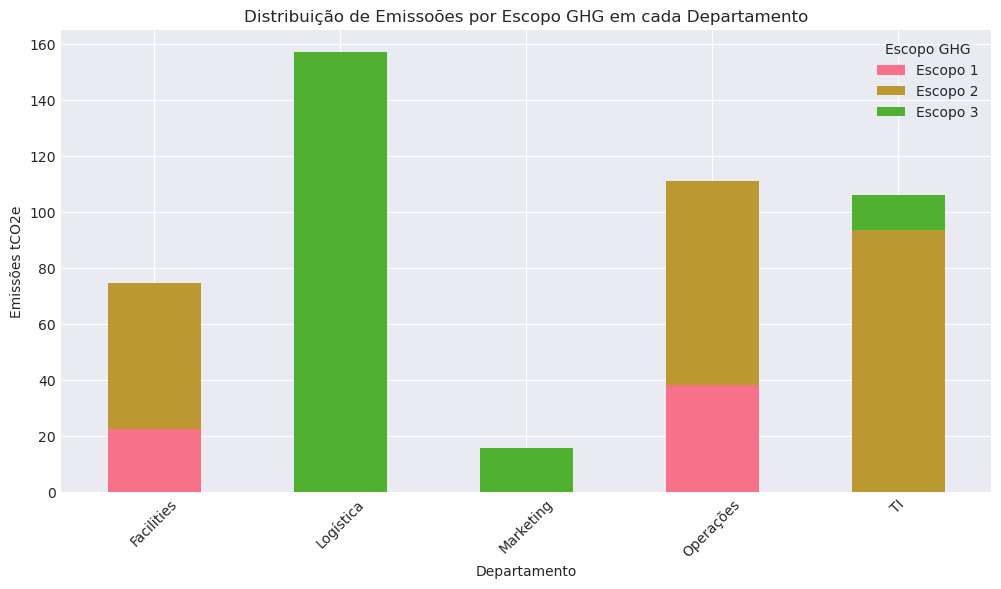

In [26]:
# 3.4 barras empilhadas com Matplotlib mostrando a distribuição de emissões por `Escopo_GHG` em cada `Departamento` 
plt.figure(figsize=(12,6))

df.pivot_table(
    values='Emissoes_tCO2e',
    index='Departamento',
    columns='Escopo_GHG',
    aggfunc='sum',
    fill_value=0
).plot(
    kind='bar',
    stacked=True,
    ax=plt.gca()
)

plt.title('Distribuição de Emissoões por Escopo GHG em cada Departamento')
plt.xlabel('Departamento')
plt.ylabel('Emissões tCO2e')
plt.legend(title='Escopo GHG')
plt.xticks(rotation=45)
plt.show()

### 4. Aplicação de Filtros

---

- Filtrar as fontes de emissão com `Emissoes_tCO2e` superior a 40 toneladas  
    _Dica: Utilize expressões booleanas para selecionar linhas baseadas em condições._
    
- Filtrar registros do `Escopo_GHG` igual a "Escopo 3" (cadeia de valor) com `Meta_Reducao_Percentual` maior ou igual a 30%  
    _Dica: Combine múltiplas condições usando o operador & (E)._
    
- Filtrar os registros do departamento "TI" e calcular o total de emissões deste departamento  
    _Dica: Filtre os dados e depois aplique sum() na coluna de emissões._
    
- **Visualização**: Criar um gráfico de pizza com Matplotlib para os dados filtrados (emissões > 40 tCO2e), mostrando a proporção de cada `Departamento` nas emissões elevadas  
    _Dica: Use plt.pie() com os dados agregados e adicione percentuais com autopct='%1.1f%%'._
    

In [34]:
# 4.1 emissoes acima de 40t
df[ df['Emissoes_tCO2e']>40 ]

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao,Emissoes_Reduzidas_Meta,Emissoes_Apos_Meta,Intensidade_Custo
0,301,TI,Data Center,Escopo 2,45.50,20,2275.00,2024-Q1,Sede SP,Energia Renovável,9.10,36.40,50.00
3,304,Facilities,Eletricidade,Escopo 2,52.10,15,2605.00,2024-Q1,Sede SP,Painéis Solares,7.82,44.29,50.00
4,305,Logística,Transporte Carga,Escopo 3,67.80,30,3390.00,2024-Q1,Centro Dist.,Otimização Rotas,20.34,47.46,50.00
8,309,Logística,Transporte Aéreo,Escopo 3,89.30,30,4465.00,2024-Q2,Centro Dist.,Compensação Carbono,26.79,62.51,50.00
11,312,Operações,Climatização,Escopo 2,41.20,15,2060.00,2024-Q3,Sede SP,HVAC Eficiente,6.18,35.02,50.00


In [33]:
# 4.2 escopo = escopo 3  e meta >= 30
df.query('Escopo_GHG == "Escopo 3" and Meta_Reducao_Percentual >= 30')

,Registro_ID,Departamento,Fonte_Emissao,Escopo_GHG,Emissoes_tCO2e,Meta_Reducao_Percentual,Custo_Compensacao_Reais,Periodo,Instalacao,Acao_Mitigacao,Emissoes_Reduzidas_Meta,Emissoes_Apos_Meta,Intensidade_Custo
4,305,Logística,Transporte Carga,Escopo 3,67.80,30,3390.00,2024-Q1,Centro Dist.,Otimização Rotas,20.34,47.46,50.00
5,306,TI,Cloud Computing,Escopo 3,12.40,40,620.00,2024-Q1,Cloud,Servidores Eficientes,4.96,7.44,50.00
8,309,Logística,Transporte Aéreo,Escopo 3,89.30,30,4465.00,2024-Q2,Centro Dist.,Compensação Carbono,26.79,62.51,50.00


In [35]:
# 4.3 total de emissoes do TI
df.query('Departamento == "TI"')['Emissoes_tCO2e'].sum()

np.float64(106.0)

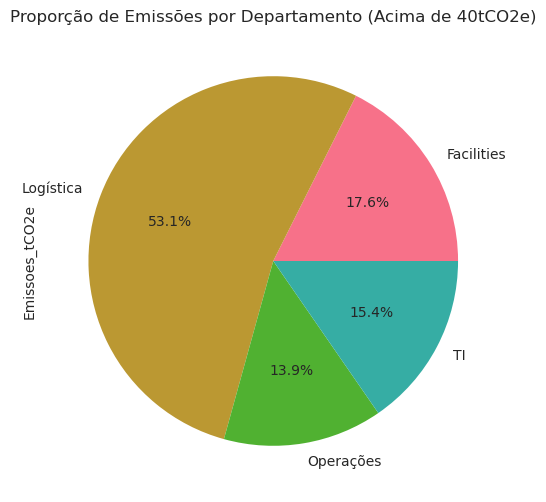

In [45]:
# 4.4  Criar um gráfico de pizza com Matplotlib para os dados filtrados (emissões > 40 tCO2e), mostrando a proporção de cada Departamento nas emissões elevadas
plt.figure(figsize=(12,6))
df.query('Emissoes_tCO2e > 40').groupby('Departamento')['Emissoes_tCO2e'].sum().plot(
    kind='pie',
    title='Proporção de Emissões por Departamento (Acima de 40tCO2e)',
    autopct='%1.1f%%'
)
plt.show()

### 5. Extra (Desafio)

---

- Extrair o trimestre e o ano da coluna `Periodo` criando duas novas colunas: `Trimestre` e `Ano`  
    _Dica: Use métodos de string como str.split() para separar os componentes ou str.extract() com regex._
    
- Criar uma nova coluna `Prioridade_Reducao` que classifique as fontes como "Alta Prioridade" (emissões > 50 tCO2e), "Média Prioridade" (25-50 tCO2e) ou "Baixa Prioridade" (< 25 tCO2e)  
    _Dica: Utilize pd.cut() com bins apropriados e labels personalizados._
    
- Identificar qual ação de mitigação está associada às maiores emissões totais e qual tem o melhor custo-benefício (menor intensidade de custo)  
    _Dica: Agrupe por Acao_Mitigacao e calcule métricas relevantes, depois use idxmax() ou idxmin()._
    
- Calcular a porcentagem de redução total que a empresa alcançaria se todas as metas fossem atingidas  
    _Dica: Compare o total de emissões atual com o total após metas usando a fórmula: (atual - projetado) / atual × 100._
    
- **Visualização**: Criar um heatmap com Seaborn mostrando a correlação entre `Emissoes_tCO2e`, `Meta_Reducao_Percentual`, `Custo_Compensacao_Reais` e `Intensidade_Custo`  
    _Dica: Use df.corr() para calcular a matriz de correlação e sns.heatmap() para visualizar, adicionando anotações com annot=True._
    

---

### 6. Análise Temporal e Comparativa (Desafio Avançado)

- Agrupar os dados por `Periodo` e calcular as emissões totais por trimestre  
    _Dica: Agrupe pela coluna Periodo e some as emissões._
    
- **Visualização**: Criar um gráfico de linha com Matplotlib mostrando a evolução das emissões totais ao longo dos trimestres  
    _Dica: Use plt.plot() com marcadores para destacar cada trimestre._
    
- Criar um gráfico de barras agrupadas comparando as emissões atuais (`Emissoes_tCO2e`) versus as emissões após meta (`Emissoes_Apos_Meta`) para cada `Departamento`  
    _Dica: Organize os dados com groupby() e plot(kind='bar') com múltiplas séries._
    
- **Visualização Avançada**: Criar um gráfico de área empilhada (stacked area chart) mostrando a contribuição de cada `Escopo_GHG` para as emissões totais ao longo do tempo  
    _Dica: Use pivot_table() para organizar os dados por Periodo e Escopo_GHG, depois plot(kind='area', stacked=True)._
    

---

## Reflexão e Perguntas Adicionais

---

Após concluir as tarefas, reflita sobre os seguintes pontos:

1. **Padrões Identificados**: Quais escopos e departamentos contribuem mais para as emissões totais? Existe correlação entre o custo de compensação e o volume de emissões? As metas de redução são ambiciosas o suficiente?
    
2. **Qualidade dos Dados**: Os dados estavam completos e bem estruturados? Como você lidaria com emissões sazonais ou com fontes que ainda não têm metas estabelecidas?
    
3. **Insights para Sustentabilidade**: Com base na sua análise, quais ações de mitigação devem ser priorizadas? Quais departamentos precisam de mais recursos para redução? A empresa está no caminho certo para a neutralidade climática?
    
4. **Próximos Passos**: Que outras análises você poderia realizar? Pense em benchmarking com concorrentes, análise de ROI das ações de mitigação, projeções de emissões futuras ou análise de ciclo de vida de produtos.
    
5. **Visualizações**: As visualizações comunicam claramente a situação ambiental da empresa? Qual gráfico foi mais efetivo para identificar oportunidades de redução de emissões?
    
6. **Contexto Global**: Considerando que o americano médio tem uma pegada de carbono de 17,6 toneladas de CO₂e por ano, mais que o dobro da média global de 6,6 toneladas, como os valores da empresa se comparam? As emissões corporativas são proporcionais ao tamanho da operação?
    

---

## Recursos Adicionais

---

Para aprofundar seus conhecimentos em análise de dados de sustentabilidade:

- **Documentação do Pandas**: https://pandas.pydata.org/docs/
- **Documentação do Matplotlib**: https://matplotlib.org/stable/contents.html
- **Documentação do Seaborn**: https://seaborn.pydata.org/
- **GHG Protocol**: https://ghgprotocol.org/ - Padrão internacional para contabilização de emissões
- **Science Based Targets**: https://sciencebasedtargets.org/ - Iniciativa para metas climáticas baseadas em ciência
- **Carbon Footprint Factsheet**: https://css.umich.edu/publications/factsheets/sustainability-indicators/carbon-footprint-factsheet
- **Tutoriais de Análise Ambiental**: Explore materiais sobre ESG (Environmental, Social, Governance) e análise de dados climáticos

---

## Vocabulário Técnico

---

- **tCO₂e** (toneladas de CO₂ equivalente): Unidade padrão que converte diferentes gases de efeito estufa em uma métrica comum
- **Escopo 1**: Emissões diretas de fontes controladas pela empresa (combustão, processos)
- **Escopo 2**: Emissões indiretas de energia comprada (eletricidade, vapor, aquecimento)
- **Escopo 3**: Outras emissões indiretas na cadeia de valor (viagens, transporte, resíduos)
- **Intensidade de Carbono**: Emissões por unidade de atividade (ex: tCO₂e por receita, por funcionário)
- **Neutralidade Climática**: Equilíbrio entre emissões produzidas e removidas da atmosfera